<a href="https://colab.research.google.com/github/hueglijoshua/CVI03.HS24-Computer-Vision/blob/main/04a_YOLO_object_detection_model_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install opencv-python pycocotools matplotlib onnxruntime onnx
!pip install segment-anything
!pip install torch torchvision
!pip install sam2


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [59]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor
import os
import subprocess
import torch
import requests
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tkinter import Tk, filedialog

In [60]:
# helper functions
def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2) 
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    coords = np.array(coords)
    labels = np.array(labels)

    pos_points = coords[labels == 1]
    neg_points = coords[labels == 0]
    
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25) 

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))    

def show_masks(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    for i, (mask, score) in enumerate(zip(masks, scores)):
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        show_mask(mask, plt.gca(), borders=borders)
        if point_coords is not None:
            assert input_labels is not None
            show_points(point_coords, input_labels, plt.gca())
        if box_coords is not None:
            # boxes
            show_box(box_coords, plt.gca())
        if len(scores) > 1:
            plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
        plt.axis('off')
        plt.show()
        

In [61]:
def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

# Selecting objects with SAM2

git clone https://github.com/facebookresearch/sam2.git && cd sam2

pip install -e .

In [5]:
%cd ./sam2

C:\Users\joshu\Documents\computervision\CVI03.HS24-Computer-Vision\sam2


C:\Users\joshu\Documents\computervision\.venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [62]:
# Step 1: Define the download URL and target file path
url = "https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt"
checkpoints_dir = "./checkpoints"
file_name = "sam2.1_hiera_large.pt"
file_path = os.path.join(checkpoints_dir, file_name)

# Step 2: Create the checkpoints directory if it doesn't exist
if not os.path.exists(checkpoints_dir):
    os.makedirs(checkpoints_dir)

# Step 3: Download the file
response = requests.get(url)

# Step 4: Save the content to the file
if response.status_code == 200:
    with open(file_path, "wb") as f:
        f.write(response.content)
    print(f"File downloaded and saved to {file_path}")
else:
    print(f"Failed to download the file. Status code: {response.status_code}")

File downloaded and saved to ./checkpoints\sam2.1_hiera_large.pt


In [63]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

In [64]:
sam2_checkpoint = "./checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"
device = "cpu"

sam2_model = build_sam2(model_cfg, sam2_checkpoint, device = device)

predictor = SAM2ImagePredictor(sam2_model)

Selected folder: C:/Users/joshu/Documents/computervision/CVI03.HS24-Computer-Vision/image_folder_ind_segmentation
Opening first image: C:/Users/joshu/Documents/computervision/CVI03.HS24-Computer-Vision/image_folder_ind_segmentation\Radiograph-of-the-right-clavicle-at-the-initial-X-ray-Anteroposterior-view-an.jpg


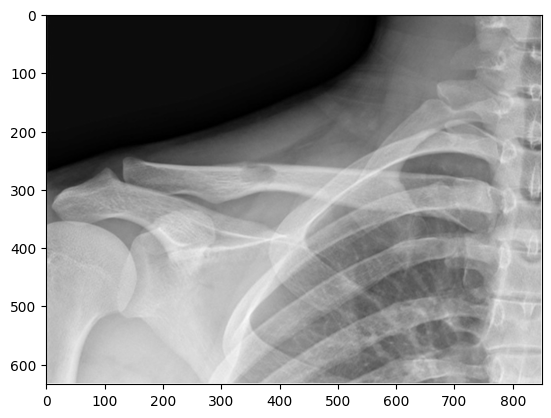

In [65]:
# Function to select a folder
def select_folder():
    root = Tk()
    root.withdraw()  # Hide the root window
    folder_selected = filedialog.askdirectory(title="Select Image Folder")
    return folder_selected

# User selects the folder
image_folder = select_folder()
print(f"Selected folder: {image_folder}")

# Get the first image in the folder
if image_folder:
    image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if image_files:
        first_image_path = os.path.join(image_folder, image_files[0])
        print(f"Opening first image: {first_image_path}")
        
        # Load the image
        image = Image.open(first_image_path)
        image = np.array(image.convert("RGB"))
        
        # Display the image
        plt.imshow(image)
        plt.axis("on")
        plt.show()
    else:
        print("No images found in the selected folder.")
else:
    print("No folder selected.")


In [66]:
predictor.set_image(image)

In [67]:
import cv2
import numpy as np
import tkinter as tk
from tkinter import simpledialog
from PIL import Image

# Initialize lists to store points and labels
input_points = []
input_labels = []

def select_point(event, x, y, flags, param):
    """Handles mouse click event to capture (x, y) coordinates and request a label."""
    global input_points, input_labels

    if event == cv2.EVENT_LBUTTONDOWN:
        # Store selected point
        input_points.append([x, y])

        # Ask user for label (Foreground: 1, Background: 0)
        root = tk.Tk()
        root.withdraw()  # Hide the main Tkinter window
        label = simpledialog.askinteger("Input", "Enter label (1 = Foreground, 0 = Background):", minvalue=0, maxvalue=1)
        
        if label is not None:
            input_labels.append(label)
            print(f"Selected point: ({x}, {y}), Label: {label}")
            # Draw the point and label on the image
            cv2.putText(image_cv, f'({x},{y}): {label}', (x + 10, y + 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
            cv2.circle(image_cv, (x, y), 5, (0, 255, 0), -1)  # Draw point on image

# Convert image from PIL to OpenCV format
image_cv = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

# Create a window and set mouse callback function
cv2.namedWindow("Select Points")
cv2.setMouseCallback("Select Points", select_point)

# Display image in pop-up window
while True:
    cv2.imshow("Select Points", image_cv)
    if cv2.waitKey(1) & 0xFF == 27:  # Press 'Esc' to exit
        break

cv2.destroyAllWindows()

# Print out all selected points and labels
print("All selected points and labels:")
for point, label in zip(input_points, input_labels):
    print(f"Point: {point}, Label: {label}")


Selected point: (163, 267), Label: 1
Selected point: (290, 302), Label: 1
Selected point: (380, 279), Label: 1
Selected point: (520, 276), Label: 1
Selected point: (537, 314), Label: 1
Selected point: (675, 289), Label: 1
Selected point: (741, 353), Label: 1
Selected point: (676, 340), Label: 1
Selected point: (410, 332), Label: 0
Selected point: (455, 345), Label: 0
Selected point: (536, 348), Label: 0
Selected point: (497, 242), Label: 0
Selected point: (563, 256), Label: 0
Selected point: (616, 263), Label: 0
Selected point: (627, 225), Label: 0
All selected points and labels:
Point: [163, 267], Label: 1
Point: [290, 302], Label: 1
Point: [380, 279], Label: 1
Point: [520, 276], Label: 1
Point: [537, 314], Label: 1
Point: [675, 289], Label: 1
Point: [741, 353], Label: 1
Point: [676, 340], Label: 1
Point: [410, 332], Label: 0
Point: [455, 345], Label: 0
Point: [536, 348], Label: 0
Point: [497, 242], Label: 0
Point: [563, 256], Label: 0
Point: [616, 263], Label: 0
Point: [627, 225], La

In [68]:
input_points

[[163, 267],
 [290, 302],
 [380, 279],
 [520, 276],
 [537, 314],
 [675, 289],
 [741, 353],
 [676, 340],
 [410, 332],
 [455, 345],
 [536, 348],
 [497, 242],
 [563, 256],
 [616, 263],
 [627, 225]]

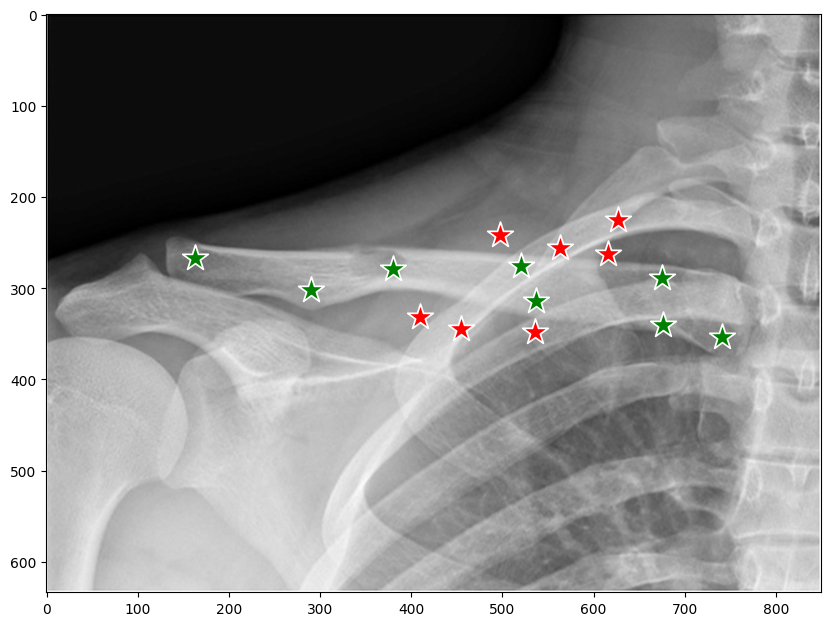

In [69]:
plt.figure(figsize=(10, 10))
plt.imshow(image)  # Use the original image (PIL format)
show_points(input_points, input_labels, plt.gca())
plt.axis('on')
plt.show()

In [70]:
masks, scores, logits = predictor.predict(
    point_coords = input_points,
    point_labels = input_labels,
    multimask_output = True,
)

In [71]:
masks.shape # (number_of_masks) x H x W

(3, 634, 850)

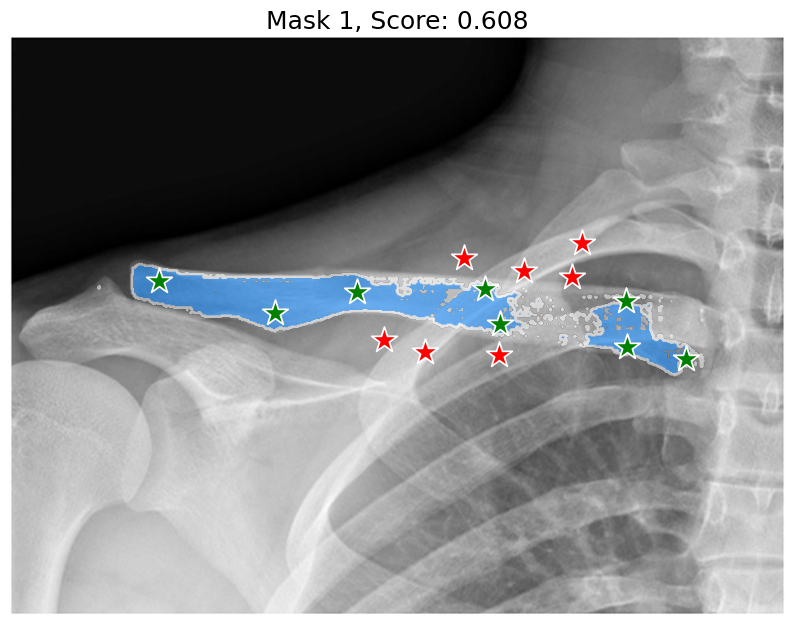

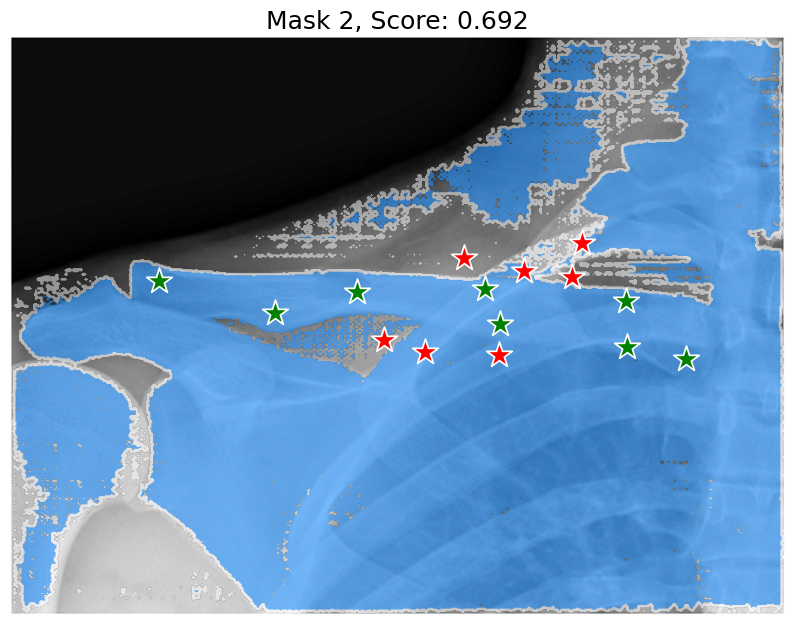

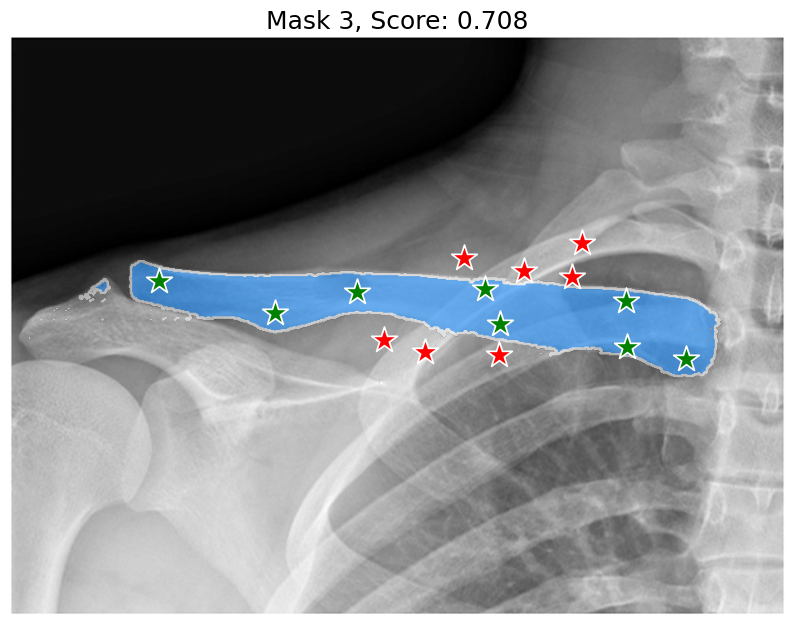

In [72]:
show_masks(image, masks, scores, point_coords=input_points, input_labels=input_labels, borders=True)

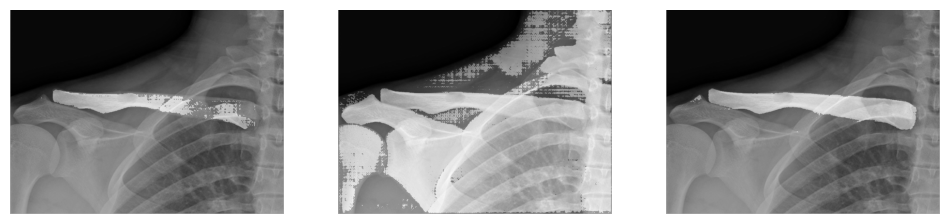

User selected Mask 3


In [73]:
import cv2
import numpy as np
import tkinter as tk
from tkinter import simpledialog
import matplotlib.pyplot as plt

# Function to display masks side-by-side without individual labels
def choose_mask(image, masks, scores):
    """Displays the three masks side by side and allows the user to select one."""
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    for i in range(3):
        mask_overlay = (masks[i] * 255).astype(np.uint8)
        image_with_mask = cv2.addWeighted(image, 0.7, cv2.cvtColor(mask_overlay, cv2.COLOR_GRAY2BGR), 0.3, 0)

        axes[i].imshow(image_with_mask)
        axes[i].axis("off")

    plt.show()

    # Ask the user for a choice (1, 2, or 3)
    root = tk.Tk()
    root.withdraw()
    choice = simpledialog.askinteger("Choose Mask", "Select a mask (1, 2, or 3):", minvalue=1, maxvalue=3)
    
    return choice - 1 if choice else 0  # Default to the first mask if no choice is made

# Predict masks
masks, scores, logits = predictor.predict(
    point_coords=input_points,
    point_labels=input_labels,
    multimask_output=True
)

# Directly use the predicted masks and scores without sorting
# Show the masks side by side without labels
selected_mask_index = choose_mask(image, masks, scores)

# Use the selected mask
mask_input = masks[selected_mask_index]
print(f"User selected Mask {selected_mask_index + 1}")